# Heart Disease Data Analysis

**Final Portfolio Project** — Codecademy Data Analyst Career Path

This project analyzes clinical and demographic data from 918 patients to identify key risk factors associated with heart disease. Through exploratory data analysis and visualization, we aim to uncover meaningful patterns that could support early detection and prevention strategies.

## Project Objectives

- Clean and prepare the heart disease dataset for analysis
- Explore relationships between clinical/demographic variables and heart disease
- Identify the strongest risk factors using statistical summaries and visualizations
- Communicate findings clearly through data storytelling and professional visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (11, 6)

# Load the dataset
df = pd.read_csv("heart_data/heart.csv")

print(f"Dataset loaded successfully. Shape: {df.shape}")
df.head()

Dataset loaded successfully. Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Data Overview

The dataset contains **918 patients** and **12 variables**. The target variable is `HeartDisease` (1 = has heart disease, 0 = no heart disease).

Key variables include:
- **Demographics**: Age, Sex
- **Clinical**: ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope

In [2]:
print("=== Data Types and Missing Values ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())

=== Data Types and Missing Values ===
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB
None

=== Missing Values ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR     

In [3]:
# Handle unrealistic zero values
print("Before cleaning:")
print(f"Cholesterol = 0: {(df['Cholesterol'] == 0).sum()} rows")
print(f"RestingBP = 0: {(df['RestingBP'] == 0).sum()} rows")

# Replace zeros with median values
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

df['Cholesterol'] = df.groupby('HeartDisease')['Cholesterol'].transform(
    lambda x: x.fillna(x.median())
)
df['RestingBP'] = df.groupby('HeartDisease')['RestingBP'].transform(
    lambda x: x.fillna(x.median())
)

print("\nAfter cleaning:")
print(f"Cholesterol = 0: {(df['Cholesterol'] == 0).sum()} rows")
print(f"RestingBP = 0: {(df['RestingBP'] == 0).sum()} rows")

Before cleaning:
Cholesterol = 0: 172 rows
RestingBP = 0: 1 rows

After cleaning:
Cholesterol = 0: 0 rows
RestingBP = 0: 0 rows


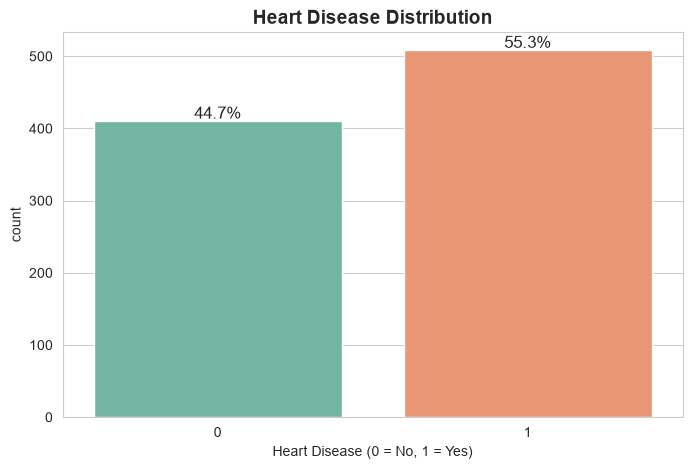

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='HeartDisease', hue='HeartDisease', palette='Set2', legend=False)
plt.title('Heart Disease Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', fontsize=12, xytext=(0, 5),
                textcoords='offset points')

plt.show()

print(df['HeartDisease'].value_counts(normalize=True) * 100)

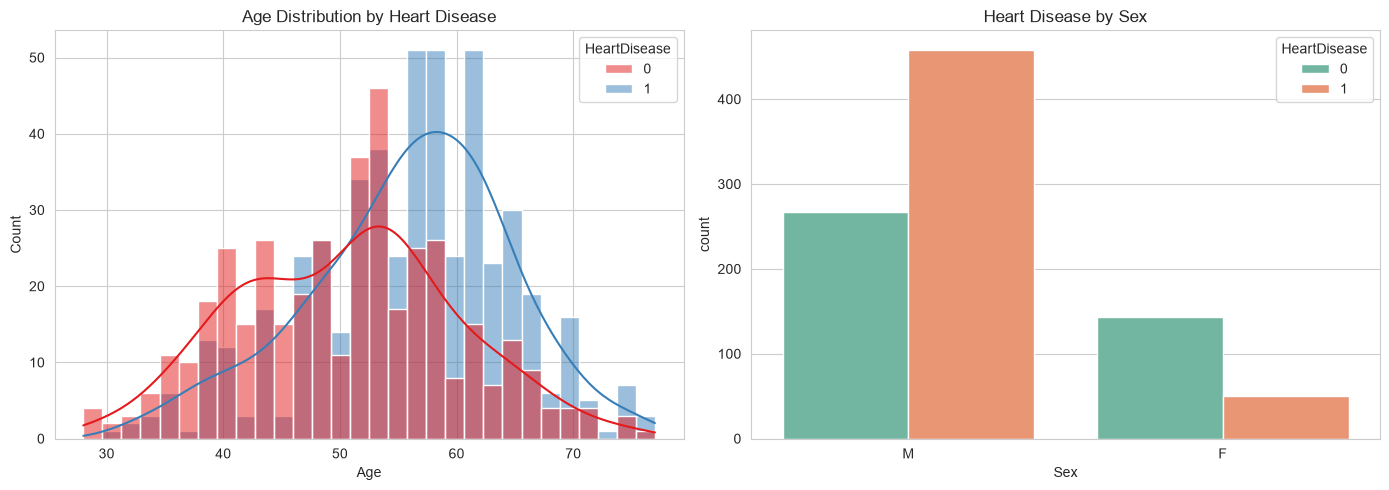

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Age', hue='HeartDisease', bins=30, kde=True, palette='Set1', ax=axes[0])
axes[0].set_title('Age Distribution by Heart Disease')

sns.countplot(data=df, x='Sex', hue='HeartDisease', palette='Set2', ax=axes[1])
axes[1].set_title('Heart Disease by Sex')

plt.tight_layout()
plt.show()

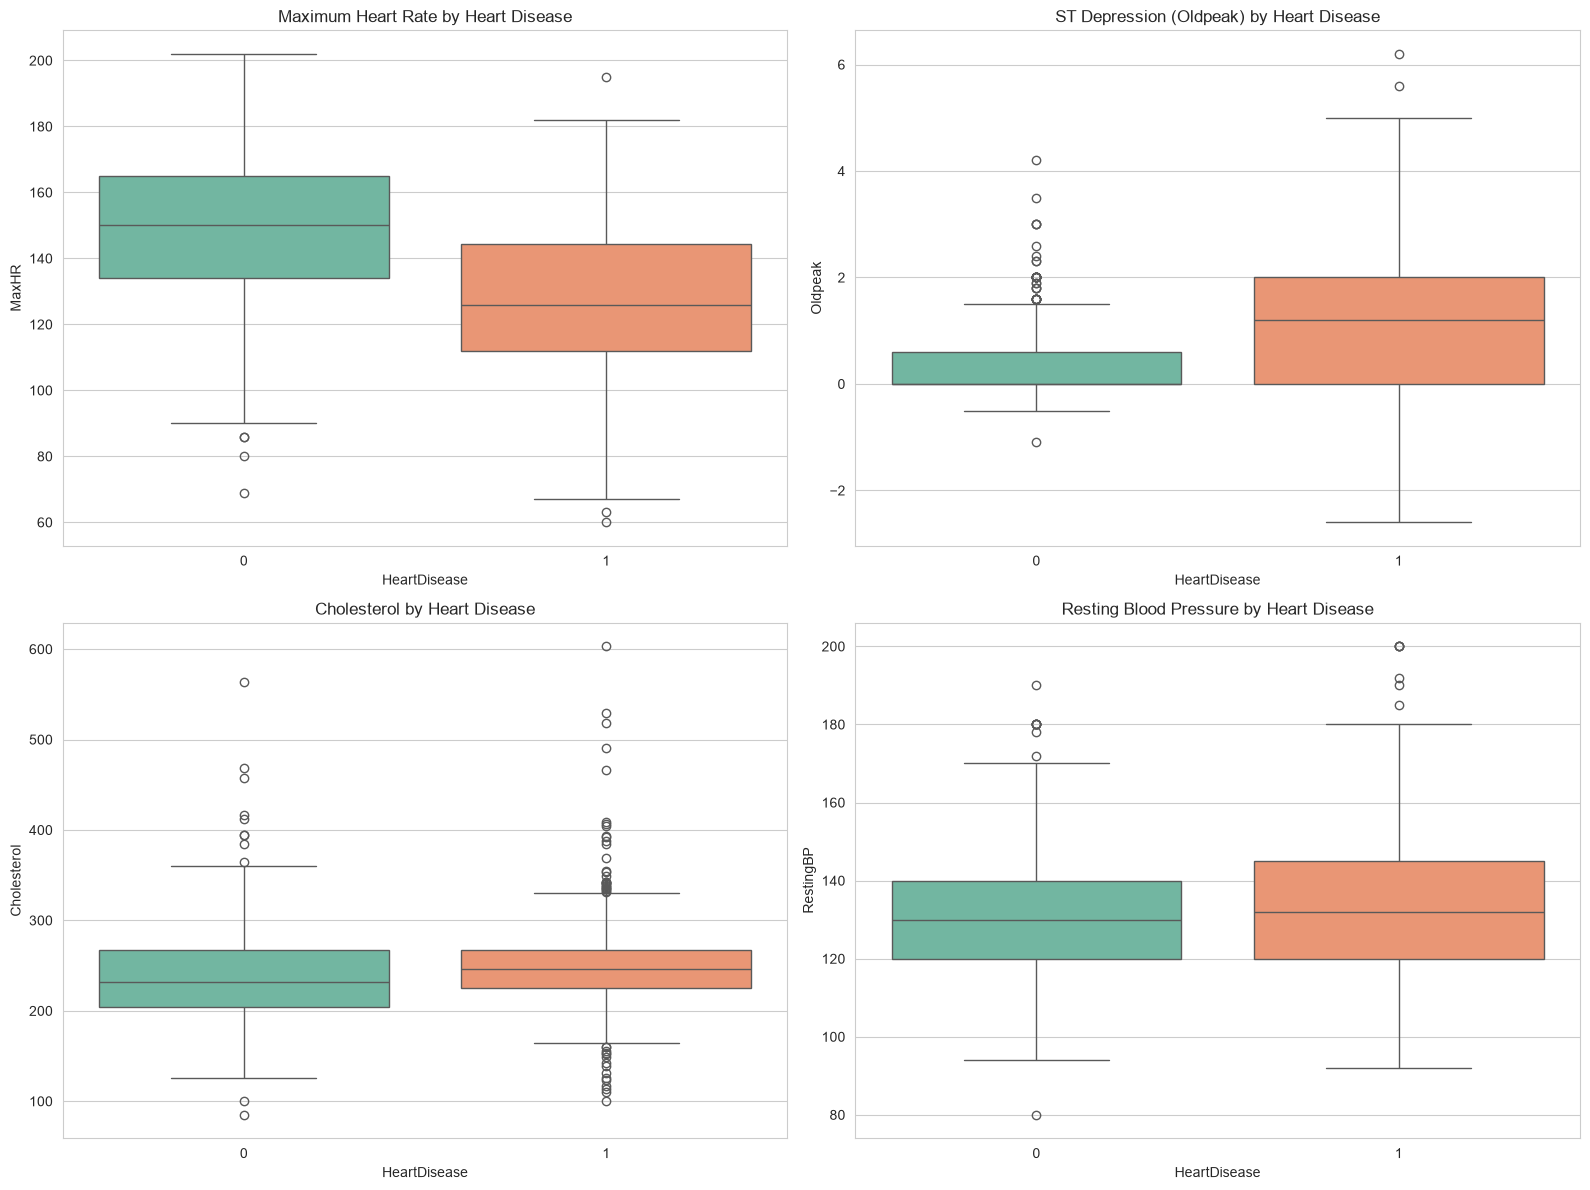

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=df, x='HeartDisease', y='MaxHR', hue='HeartDisease', palette='Set2', legend=False, ax=axes[0,0])
axes[0,0].set_title('Maximum Heart Rate by Heart Disease')

sns.boxplot(data=df, x='HeartDisease', y='Oldpeak', hue='HeartDisease', palette='Set2', legend=False, ax=axes[0,1])
axes[0,1].set_title('ST Depression (Oldpeak) by Heart Disease')

sns.boxplot(data=df, x='HeartDisease', y='Cholesterol', hue='HeartDisease', palette='Set2', legend=False, ax=axes[1,0])
axes[1,0].set_title('Cholesterol by Heart Disease')

sns.boxplot(data=df, x='HeartDisease', y='RestingBP', hue='HeartDisease', palette='Set2', legend=False, ax=axes[1,1])
axes[1,1].set_title('Resting Blood Pressure by Heart Disease')

plt.tight_layout()
plt.show()

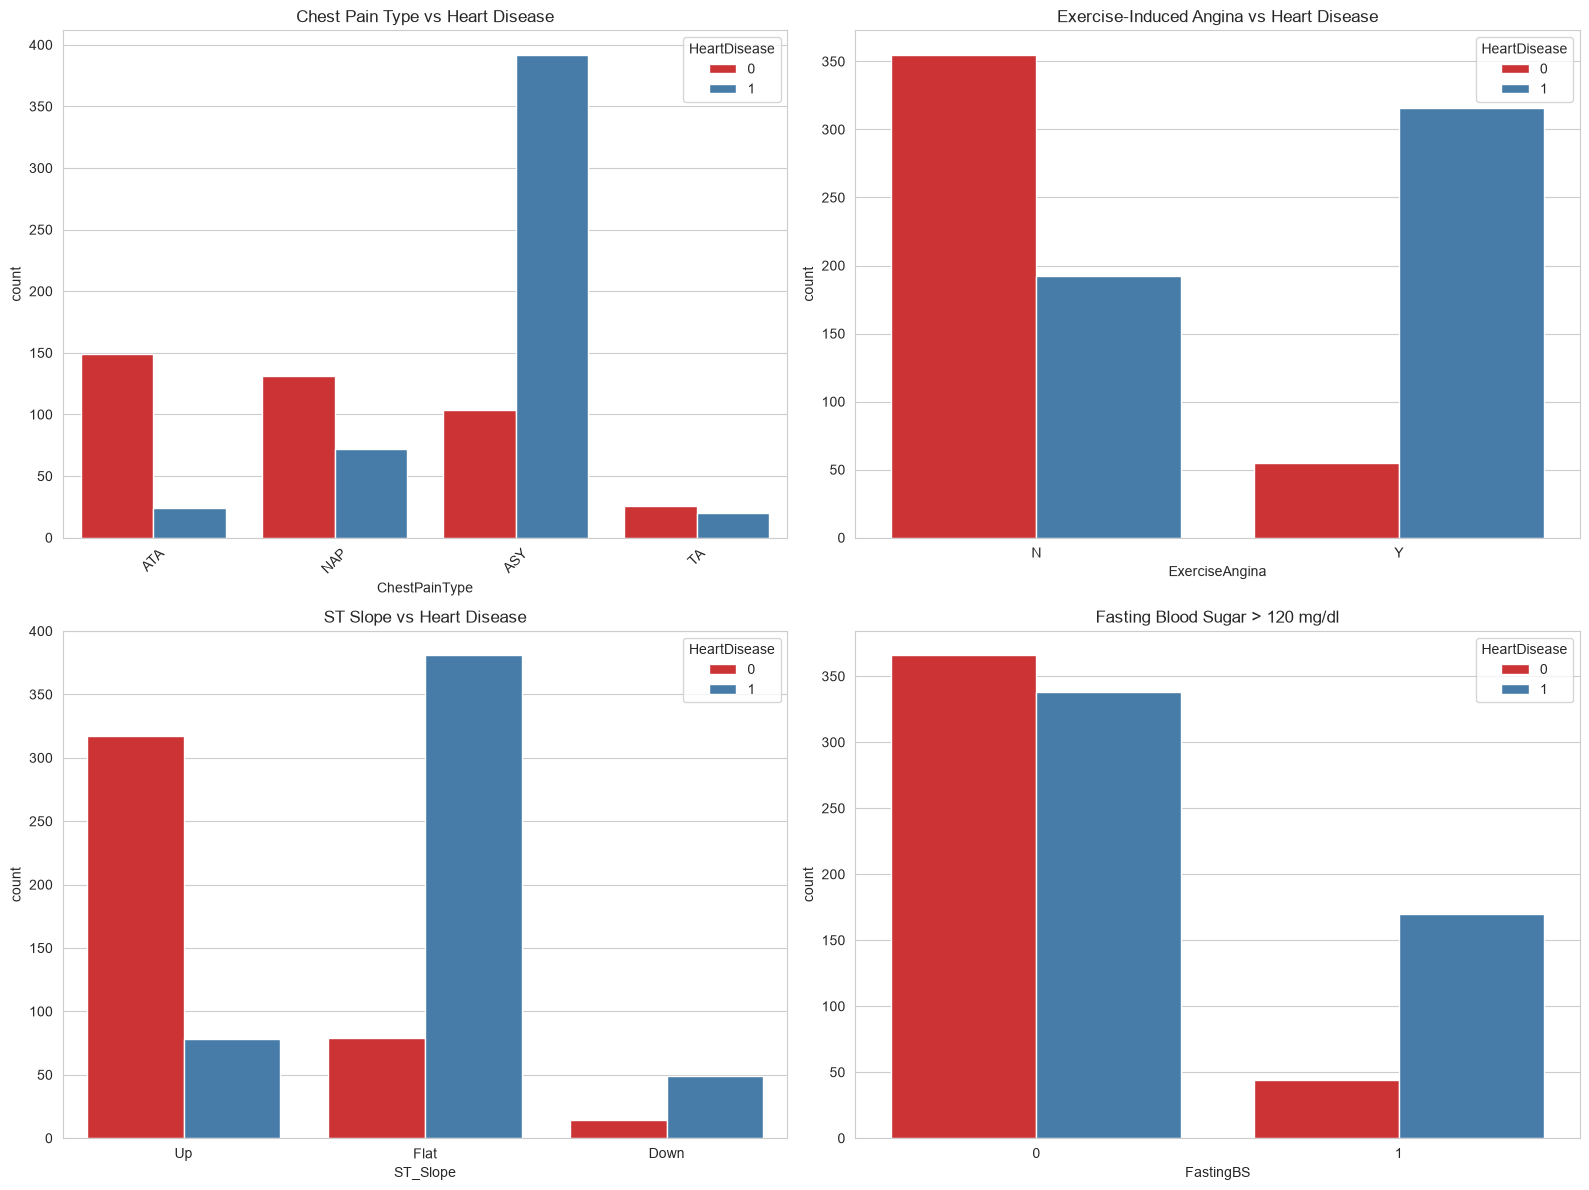

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(data=df, x='ChestPainType', hue='HeartDisease', palette='Set1', ax=axes[0,0])
axes[0,0].set_title('Chest Pain Type vs Heart Disease')
axes[0,0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='ExerciseAngina', hue='HeartDisease', palette='Set1', ax=axes[0,1])
axes[0,1].set_title('Exercise-Induced Angina vs Heart Disease')

sns.countplot(data=df, x='ST_Slope', hue='HeartDisease', palette='Set1', ax=axes[1,0])
axes[1,0].set_title('ST Slope vs Heart Disease')

sns.countplot(data=df, x='FastingBS', hue='HeartDisease', palette='Set1', ax=axes[1,1])
axes[1,1].set_title('Fasting Blood Sugar > 120 mg/dl')

plt.tight_layout()
plt.show()

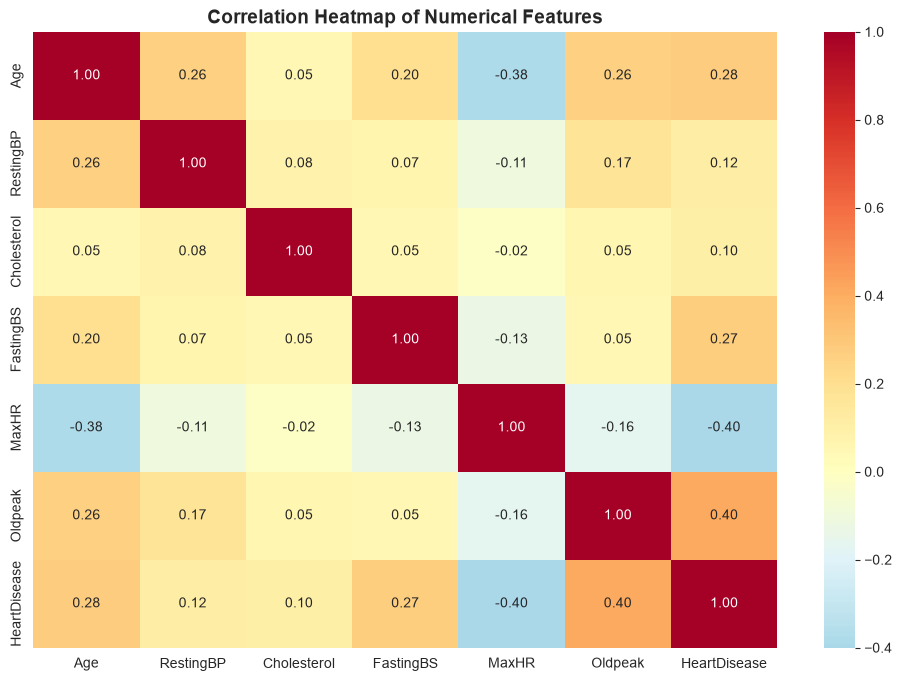

In [8]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlBu_r', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.show()

## Key Findings & Conclusions

### Top Risk Factors Identified

After thorough exploratory data analysis, the following factors showed the **strongest associations** with heart disease:

| Rank | Factor                    | Observation                                                                 | Strength     |
|------|---------------------------|-----------------------------------------------------------------------------|--------------|
| 1    | **ExerciseAngina**        | Patients with exercise-induced angina have dramatically higher rates of heart disease | Very Strong |
| 2    | **ST_Slope**              | Flat or Downsloping ST segments are strongly linked to heart disease        | Very Strong |
| 3    | **ChestPainType (ASY)**   | Asymptomatic chest pain shows very high association with heart disease      | Strong      |
| 4    | **MaxHR**                 | Lower maximum heart rate is consistently associated with heart disease      | Strong      |
| 5    | **Oldpeak**               | Higher ST depression values correlate with increased heart disease risk     | Strong      |
| 6    | **Age**                   | Risk increases significantly with age                                       | Moderate-Strong |
| 7    | **Sex**                   | Males show notably higher rates of heart disease than females               | Moderate    |

### Additional Insights

- A large proportion of heart disease cases in this dataset were **asymptomatic** (no typical chest pain), highlighting the importance of other diagnostic indicators.
- After cleaning unrealistic zero values, **Cholesterol** and **Resting Blood Pressure** showed weaker direct relationships than initially expected.
- The combination of **ExerciseAngina + Flat/Downsloping ST_Slope** appears to represent a particularly high-risk profile.

### Actionable Takeaways

This analysis suggests that screening and prevention efforts should prioritize patients with:
- Exercise-induced angina
- Abnormal ST slope on ECG
- Lower maximum heart rate
- Older age (especially males)

These factors could help identify high-risk individuals earlier.

### Skills Demonstrated

- Data cleaning and handling of unrealistic/missing values
- Exploratory data analysis with both numerical and categorical variables
- Effective use of visualizations to uncover patterns
- Clear communication of findings through narrative and data storytelling